# Model Comparison for ECHR Outcome Prediction

This notebook compares three models on the same fixed `train / val / test` split:
- Multinomial Naive Bayes with word n-grams
- Linear SVM with char n-grams
- Legal-BERT (`nlpaueb/legal-bert-base-uncased`)

The goal is to compare performance and error patterns before deciding the next modeling step.


## Notebook Use

This notebook is set up in a pragmatic way:
- By default it **reuses the existing split and existing Legal-BERT outputs**.
- Naive Bayes and Linear SVM are trained inline in the notebook for transparent comparison.
- Legal-BERT can be rerun from the notebook, but the switch is off by default because it is slower.
- The top config cell separates **`DATASET_DIR`** (read-only input) and **`WORKING_DIR`** (writable output), which matches Kaggle's storage pattern.

Success criteria:
- Compare the three models on exactly the same test split.
- Visualize metric differences, confusion matrices, and country-level behavior.
- Identify whether the transformer is actually stronger or only appears strong because of class skew.


In [1]:
from pathlib import Path
import json
import os
import random
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path('.').resolve()
DATASET_DIR = PROJECT_DIR
WORKING_DIR = PROJECT_DIR

# Kaggle example:
DATASET_DIR = Path('/kaggle/input/datasets/seaskyjj/echrdata')
WORKING_DIR = Path('/kaggle/working')

PYTHON_BIN = Path(sys.executable)
RESULTS_DIR = WORKING_DIR / 'results'
CLASSICAL_DIR = RESULTS_DIR / 'classical'
LEGAL_BERT_DIR = RESULTS_DIR / 'legal_bert'
LEGAL_BERT_BASE_MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'
LEGAL_BERT_BASE_DIR = WORKING_DIR / 'models' / 'legal_bert_base_uncased'
LONGFORMER_DIR = RESULTS_DIR / 'longformer_4096'
LONGFORMER_MODEL_NAME = 'allenai/longformer-base-4096'
HF_HOME_DIR = WORKING_DIR / '.cache' / 'huggingface'
HF_HUB_DIR = HF_HOME_DIR / 'hub'
HF_TRANSFORMERS_DIR = HF_HOME_DIR / 'transformers'
RAW_DIR = DATASET_DIR / 'data' / 'raw'
INPUT_PROCESSED_DIR = DATASET_DIR / 'data' / 'processed'
WORKING_PROCESSED_DIR = WORKING_DIR / 'data' / 'processed'
PROCESSED_DIR = WORKING_PROCESSED_DIR if (WORKING_PROCESSED_DIR / 'train.csv').exists() else INPUT_PROCESSED_DIR

RUN_SPLIT = False
AUTO_SPLIT_IF_MISSING = True
RUN_LEGAL_BERT = False
AUTO_TRAIN_LEGAL_BERT_IF_MISSING = True
AUTO_DOWNLOAD_LEGAL_BERT_BASE = True
LEGAL_BERT_ARTIFACT_DIR = None
AUTO_TRAIN_LONGFORMER_IF_MISSING = False
LONGFORMER_ARTIFACT_DIR = None
LEGAL_BERT_EPOCHS = 3
LEGAL_BERT_BATCH_SIZE = 4
LEGAL_BERT_LEARNING_RATE = 2e-5
LEGAL_BERT_WEIGHT_DECAY = 0.01
LEGAL_BERT_WARMUP_RATIO = 0.10
LEGAL_BERT_GRAD_ACCUM_STEPS = 1
LEGAL_BERT_EARLY_STOPPING_PATIENCE = 1
LEGAL_BERT_EARLY_STOPPING_THRESHOLD = 0.0
LEGAL_BERT_USE_WEIGHTED_LOSS = False
LEGAL_BERT_USE_WEIGHTED_SAMPLER = False
LEGAL_BERT_USE_THRESHOLD_TUNING = False
LEGAL_BERT_THRESHOLD_GRID_SIZE = 181
LEGAL_BERT_THRESHOLD_METRIC = 'balanced_accuracy'
LONGFORMER_EPOCHS = 2
LONGFORMER_BATCH_SIZE = 1
LONGFORMER_MAX_LEN = 4096
LONGFORMER_LEARNING_RATE = 1e-5
LONGFORMER_WEIGHT_DECAY = 0.01
LONGFORMER_WARMUP_RATIO = 0.10
LONGFORMER_GRAD_ACCUM_STEPS = 4
LONGFORMER_EARLY_STOPPING_PATIENCE = 1
LONGFORMER_EARLY_STOPPING_THRESHOLD = 0.0
LONGFORMER_USE_WEIGHTED_LOSS = True
LONGFORMER_USE_WEIGHTED_SAMPLER = False
LONGFORMER_USE_THRESHOLD_TUNING = False
LONGFORMER_THRESHOLD_GRID_SIZE = 181
LONGFORMER_THRESHOLD_METRIC = 'balanced_accuracy'
LONGFORMER_GRADIENT_CHECKPOINTING = True
LONGFORMER_EVAL_ACCUMULATION_STEPS = 8
LONGFORMER_FORCE_SINGLE_GPU = True
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
MAX_LEN = 512

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

MODEL_DISPLAY = {
    'naive_bayes_word': 'Naive Bayes',
    'linear_svm_char': 'Linear SVM',
    'legal_bert': 'Legal-BERT',
    'longformer_4096': 'Longformer-4096',
}

MODEL_COLORS = {
    'Naive Bayes': '#d95f02',
    'Linear SVM': '#1b9e77',
    'Legal-BERT': '#7570b3',
    'Longformer-4096': '#e7298a',
}


def display_path(path):
    path = Path(path)
    try:
        return str(path.relative_to(PROJECT_DIR))
    except ValueError:
        return str(path)


def huggingface_env():
    env = os.environ.copy()
    env['HF_HOME'] = str(HF_HOME_DIR)
    env['HUGGINGFACE_HUB_CACHE'] = str(HF_HUB_DIR)
    env['TRANSFORMERS_CACHE'] = str(HF_TRANSFORMERS_DIR)
    return env


## 1. Ensure the Fixed Split Exists

This notebook no longer depends on `scripts/split_data.py`.
If `RUN_SPLIT = True`, or if split files are missing and `AUTO_SPLIT_IF_MISSING = True`, it will create:
- `train.csv`
- `val.csv`
- `test.csv`
- `metadata_joined_test.csv`

All of that now happens inside the notebook.


In [2]:
def make_strata(df):
    return df['respondent'].astype(str) + '__' + df['label'].astype(str)


def stratified_train_val_test_split(df, train_size=TRAIN_SIZE, val_size=VAL_SIZE, test_size=TEST_SIZE, seed=SEED):
    total = train_size + val_size + test_size
    if abs(total - 1.0) > 1e-9:
        raise ValueError('train_size + val_size + test_size must equal 1.0')

    strata = make_strata(df)
    outer = StratifiedShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    train_idx, temp_idx = next(outer.split(df, strata))
    train_df = df.iloc[train_idx].copy().reset_index(drop=True)
    temp_df = df.iloc[temp_idx].copy().reset_index(drop=True)

    temp_val_share = val_size / (val_size + test_size)
    inner = StratifiedShuffleSplit(n_splits=1, train_size=temp_val_share, random_state=seed)
    val_idx, test_idx = next(inner.split(temp_df, make_strata(temp_df)))
    val_df = temp_df.iloc[val_idx].copy().reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].copy().reset_index(drop=True)
    return train_df, val_df, test_df


def create_metadata_joined_test(test_df, metadata_path):
    meta_df = pd.read_csv(metadata_path)
    test_df = test_df.copy()
    meta_df = meta_df.copy()
    test_df['item_id'] = test_df['item_id'].astype(str)
    meta_df['itemid'] = meta_df['itemid'].astype(str)
    return test_df.merge(meta_df, left_on='item_id', right_on='itemid', how='left', suffixes=('', '_meta'))


def ensure_split_files(processed_dir):
    train_path = processed_dir / 'train.csv'
    val_path = processed_dir / 'val.csv'
    test_path = processed_dir / 'test.csv'
    joined_path = processed_dir / 'metadata_joined_test.csv'

    if train_path.exists() and val_path.exists() and test_path.exists() and joined_path.exists() and not RUN_SPLIT:
        return processed_dir

    if not (AUTO_SPLIT_IF_MISSING or RUN_SPLIT):
        missing = [p.name for p in [train_path, val_path, test_path, joined_path] if not p.exists()]
        raise FileNotFoundError(f'Missing split files in {processed_dir}: {missing}')

    processed_dir.mkdir(parents=True, exist_ok=True)
    processed_csv_path = INPUT_PROCESSED_DIR / 'processed.csv'
    metadata_path = RAW_DIR / 'metadata.csv'
    if not processed_csv_path.exists():
        raise FileNotFoundError(f'Missing processed dataset: {processed_csv_path}')
    if not metadata_path.exists():
        raise FileNotFoundError(f'Missing metadata file: {metadata_path}')

    processed_df = pd.read_csv(processed_csv_path)
    train_df, val_df, test_df = stratified_train_val_test_split(processed_df)
    metadata_joined_test = create_metadata_joined_test(test_df, metadata_path)

    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)
    test_df.to_csv(test_path, index=False)
    metadata_joined_test.to_csv(joined_path, index=False)
    return processed_dir


PROCESSED_DIR = ensure_split_files(WORKING_PROCESSED_DIR if RUN_SPLIT or AUTO_SPLIT_IF_MISSING else PROCESSED_DIR)
train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv')
metadata_joined_test = pd.read_csv(PROCESSED_DIR / 'metadata_joined_test.csv')

print('processed_dir', display_path(PROCESSED_DIR))
print('train', train_df.shape)
print('val', val_df.shape)
print('test', test_df.shape)
print('test label counts', test_df['label'].value_counts().sort_index().to_dict())
print('test respondent counts', test_df['respondent'].value_counts().sort_index().to_dict())


processed_dir data/processed
train (493, 7)
val (106, 7)
test (106, 7)
test label counts {0: 33, 1: 73}
test respondent counts {'GBR': 35, 'RUS': 46, 'TUR': 25}


## 2. Classical Models in Notebook

These two functions reproduce the selected classical baselines on the same split:
- Naive Bayes: word unigrams + bigrams with count features
- Linear SVM: character `char_wb` 3-5 grams with TF-IDF

To match the project pipeline, both are fit on `train + val` and evaluated on `test`.


In [3]:
def compute_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='binary',
        zero_division=0,
    )
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
    }


def build_naive_bayes(seed=SEED):
    return Pipeline([
        ('vectorizer', CountVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            min_df=2,
            lowercase=True,
        )),
        ('classifier', MultinomialNB(alpha=0.5)),
    ])


def build_linear_svm(seed=SEED):
    return Pipeline([
        ('vectorizer', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            min_df=2,
            lowercase=True,
            sublinear_tf=True,
        )),
        ('classifier', LinearSVC(
            C=1.0,
            class_weight='balanced',
            random_state=seed,
        )),
    ])


def predict_with_scores(model, texts):
    preds = model.predict(texts)
    classifier = model.named_steps['classifier']
    if hasattr(classifier, 'predict_proba'):
        scores = model.predict_proba(texts)[:, 1]
    elif hasattr(classifier, 'decision_function'):
        scores = model.decision_function(texts)
    else:
        scores = np.full(len(preds), np.nan)
    return preds, scores


def evaluate_classical_model(model, train_val_df, test_df, model_key):
    model.fit(train_val_df['text'], train_val_df['label'])
    preds, scores = predict_with_scores(model, test_df['text'])
    metrics = compute_metrics(test_df['label'], preds)
    pred_df = test_df[['item_id', 'label', 'respondent', 'year']].copy()
    pred_df['prediction'] = preds
    pred_df['score'] = scores
    pred_df['correct'] = (pred_df['label'] == pred_df['prediction']).astype(int)
    pred_df['model_key'] = model_key
    pred_df['model_name'] = MODEL_DISPLAY[model_key]
    return metrics, pred_df, model


In [4]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

nb_metrics, nb_pred, nb_model = evaluate_classical_model(
    build_naive_bayes(),
    train_val_df,
    test_df,
    'naive_bayes_word',
)

svm_metrics, svm_pred, svm_model = evaluate_classical_model(
    build_linear_svm(),
    train_val_df,
    test_df,
    'linear_svm_char',
)

print('Naive Bayes:', nb_metrics)
print('Linear SVM:', svm_metrics)


Naive Bayes: {'accuracy': 0.7452830188679245, 'precision': 0.8285714285714286, 'recall': 0.7945205479452054, 'f1': 0.8111888111888111, 'macro_f1': 0.7099422316813622, 'balanced_accuracy': 0.7154420921544209}
Linear SVM: {'accuracy': 0.7452830188679245, 'precision': 0.8382352941176471, 'recall': 0.7808219178082192, 'f1': 0.8085106382978723, 'macro_f1': 0.7141144740785136, 'balanced_accuracy': 0.7237442922374429}


## 3. Legal-BERT

This section is split into helper definitions and a separate train/run block so you can rerun Legal-BERT with different epoch settings without touching the rest of the notebook.


In [5]:
import inspect
import torch
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader, WeightedRandomSampler
from transformers import Trainer, TrainingArguments


def ensure_legal_bert_base_model():
    if (LEGAL_BERT_BASE_DIR / 'config.json').exists():
        return LEGAL_BERT_BASE_DIR

    if not AUTO_DOWNLOAD_LEGAL_BERT_BASE:
        raise FileNotFoundError(
            f'Base Legal-BERT model not found at {LEGAL_BERT_BASE_DIR}. '
            'Enable AUTO_DOWNLOAD_LEGAL_BERT_BASE or place the model there manually.'
        )

    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    LEGAL_BERT_BASE_DIR.mkdir(parents=True, exist_ok=True)
    HF_HOME_DIR.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(
        LEGAL_BERT_BASE_MODEL_NAME,
        cache_dir=str(HF_TRANSFORMERS_DIR),
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        LEGAL_BERT_BASE_MODEL_NAME,
        num_labels=2,
        cache_dir=str(HF_TRANSFORMERS_DIR),
    )
    tokenizer.save_pretrained(LEGAL_BERT_BASE_DIR)
    model.save_pretrained(LEGAL_BERT_BASE_DIR)
    return LEGAL_BERT_BASE_DIR


def detect_device():
    if torch.cuda.is_available():
        return 'cuda'
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


def extract_logits(predictions):
    if isinstance(predictions, tuple):
        return predictions[0]
    return predictions


def softmax_probs(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def compute_hf_metrics(pred):
    labels = pred.label_ids
    logits = extract_logits(pred.predictions)
    preds = logits.argmax(-1)
    return compute_metrics(labels, preds)


class ECHRTextDataset:
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoding = self.tokenizer(
            str(row['text']),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(int(row['label']), dtype=torch.long),
        }


def compute_class_weights(labels):
    counts = labels.value_counts().sort_index()
    num_classes = len(counts)
    total = int(counts.sum())
    weights = [total / (num_classes * counts[idx]) for idx in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float)


def compute_sample_weights(labels):
    counts = labels.value_counts().sort_index()
    per_class = {cls: 1.0 / count for cls, count in counts.items()}
    return labels.map(per_class).astype(float).to_numpy()


def threshold_objective_value(metrics, metric_name):
    if metric_name not in {'f1', 'macro_f1', 'balanced_accuracy'}:
        raise ValueError(f'Unsupported threshold metric: {metric_name}')
    return float(metrics[metric_name])


def tune_binary_threshold(y_true, positive_probs, grid_size=181, metric_name='balanced_accuracy'):
    candidate_thresholds = np.linspace(0.01, 0.99, grid_size)
    best = None
    for threshold in candidate_thresholds:
        preds = (positive_probs >= threshold).astype(int)
        metrics = compute_metrics(y_true, preds)
        score = (
            threshold_objective_value(metrics, metric_name),
            metrics['accuracy'],
            -abs(float(threshold) - 0.5),
        )
        if best is None or score > best['score']:
            best = {
                'threshold': float(threshold),
                'metrics': metrics,
                'score': score,
                'threshold_metric': metric_name,
            }
    return best


class ImbalanceAwareTrainer(Trainer):
    def __init__(
        self,
        *args,
        class_weights=None,
        use_weighted_loss=False,
        sample_weights=None,
        use_weighted_sampler=False,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_weighted_loss = use_weighted_loss
        self.sample_weights = sample_weights
        self.use_weighted_sampler = use_weighted_sampler

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        if not self.use_weighted_loss:
            return super().compute_loss(model, inputs, return_outputs=return_outputs, **kwargs)

        labels = inputs.get('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        base_model = model.module if hasattr(model, 'module') else model
        num_labels = getattr(getattr(base_model, 'config', None), 'num_labels', logits.shape[-1])
        loss_fct = CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        if not self.use_weighted_sampler:
            return super().get_train_dataloader()
        if self.train_dataset is None:
            raise ValueError('Trainer requires a train_dataset when weighted sampler is enabled.')

        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(self.sample_weights, dtype=torch.double),
            num_samples=len(self.sample_weights),
            replacement=True,
        )
        return DataLoader(
            self.train_dataset,
            batch_size=self._train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )


def build_training_arguments(
    output_dir,
    num_train_epochs,
    batch_size,
    learning_rate,
    weight_decay,
    warmup_ratio,
    grad_accum_steps,
    device,
    gradient_checkpointing=False,
    eval_accumulation_steps=None,
    force_single_gpu=False,
):
    training_kwargs = {
        'output_dir': str(output_dir),
        'num_train_epochs': num_train_epochs,
        'per_device_train_batch_size': batch_size,
        'per_device_eval_batch_size': batch_size,
        'learning_rate': learning_rate,
        'weight_decay': weight_decay,
        'warmup_ratio': warmup_ratio,
        'gradient_accumulation_steps': grad_accum_steps,
        'logging_steps': 10,
        'load_best_model_at_end': True,
        'metric_for_best_model': 'f1',
        'greater_is_better': True,
        'seed': SEED,
        'data_seed': SEED,
        'report_to': 'none',
        'save_total_limit': 2,
        'fp16': (device == 'cuda'),
    }
    init_params = set(inspect.signature(TrainingArguments.__init__).parameters)
    eval_key = 'eval_strategy' if 'eval_strategy' in init_params else 'evaluation_strategy'
    training_kwargs[eval_key] = 'epoch'
    training_kwargs['save_strategy'] = 'epoch'
    if gradient_checkpointing:
        training_kwargs['gradient_checkpointing'] = True
    if eval_accumulation_steps is not None:
        training_kwargs['eval_accumulation_steps'] = eval_accumulation_steps
    training_args = TrainingArguments(**training_kwargs)
    if force_single_gpu and device == 'cuda':
        training_args._n_gpu = 1
    return training_args


def prediction_frame(df, logits, preds, threshold_used=None, mode='default'):
    probs = softmax_probs(logits)
    pred_df = df.copy()
    pred_df['prediction'] = preds.astype(int)
    pred_df['logit_0'] = logits[:, 0]
    pred_df['logit_1'] = logits[:, 1]
    pred_df['prob_1'] = probs[:, 1]
    pred_df['score'] = pred_df['prob_1']
    pred_df['correct'] = (pred_df['label'] == pred_df['prediction']).astype(int)
    pred_df['prediction_mode'] = mode
    pred_df['threshold_used'] = np.nan if threshold_used is None else float(threshold_used)
    return pred_df


def save_json(path, payload):
    Path(path).write_text(json.dumps(payload, indent=2), encoding='utf-8')


def train_transformer_classifier_inline(
    model_source,
    max_len,
    output_dir,
    learning_rate,
    weight_decay,
    warmup_ratio,
    grad_accum_steps,
    early_stopping_patience,
    early_stopping_threshold,
    use_weighted_loss,
    use_weighted_sampler,
    use_threshold_tuning,
    threshold_grid_size,
    threshold_metric,
    num_train_epochs,
    batch_size,
    gradient_checkpointing=False,
    eval_accumulation_steps=None,
    force_single_gpu=False,
    cache_dir=None,
):
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        EarlyStoppingCallback,
        set_seed,
    )

    set_seed(SEED)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    device = detect_device()

    tokenizer_kwargs = {}
    model_kwargs = {'num_labels': 2}
    if cache_dir is not None:
        tokenizer_kwargs['cache_dir'] = cache_dir
        model_kwargs['cache_dir'] = cache_dir

    tokenizer = AutoTokenizer.from_pretrained(model_source, **tokenizer_kwargs)
    tokenizer.model_max_length = int(max_len)
    model = AutoModelForSequenceClassification.from_pretrained(model_source, **model_kwargs)
    if gradient_checkpointing and hasattr(model, 'gradient_checkpointing_enable'):
        model.gradient_checkpointing_enable()
    if device in {'cuda', 'mps'}:
        model.to(device)

    train_dataset = ECHRTextDataset(train_df, tokenizer, max_len)
    val_dataset = ECHRTextDataset(val_df, tokenizer, max_len)
    test_dataset = ECHRTextDataset(test_df, tokenizer, max_len)

    class_weights = compute_class_weights(train_df['label'])
    sample_weights = compute_sample_weights(train_df['label'])
    print('class_weights', [round(float(x), 4) for x in class_weights.tolist()])
    print('weighted_loss', use_weighted_loss)
    print('weighted_sampler', use_weighted_sampler)
    print('threshold_tuning', use_threshold_tuning)
    print('threshold_metric', threshold_metric)
    print('gradient_checkpointing', gradient_checkpointing)
    print('eval_accumulation_steps', eval_accumulation_steps)
    print('force_single_gpu', force_single_gpu)

    training_args = build_training_arguments(
        output_dir=output_dir,
        num_train_epochs=num_train_epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        grad_accum_steps=grad_accum_steps,
        device=device,
        gradient_checkpointing=gradient_checkpointing,
        eval_accumulation_steps=eval_accumulation_steps,
        force_single_gpu=force_single_gpu,
    )

    callbacks = []
    if early_stopping_patience is not None:
        callbacks.append(
            EarlyStoppingCallback(
                early_stopping_patience=early_stopping_patience,
                early_stopping_threshold=early_stopping_threshold,
            )
        )

    trainer_kwargs = {
        'model': model,
        'args': training_args,
        'train_dataset': train_dataset,
        'eval_dataset': val_dataset,
        'compute_metrics': compute_hf_metrics,
        'class_weights': class_weights,
        'use_weighted_loss': use_weighted_loss,
        'sample_weights': sample_weights,
        'use_weighted_sampler': use_weighted_sampler,
    }
    trainer_init_params = set(inspect.signature(Trainer.__init__).parameters)
    if 'processing_class' in trainer_init_params:
        trainer_kwargs['processing_class'] = tokenizer
    elif 'tokenizer' in trainer_init_params:
        trainer_kwargs['tokenizer'] = tokenizer
    if callbacks:
        trainer_kwargs['callbacks'] = callbacks

    trainer = ImbalanceAwareTrainer(**trainer_kwargs)
    trainer.train()
    trainer.save_model(str(output_dir / 'final_model'))
    tokenizer.save_pretrained(str(output_dir / 'final_model'))

    val_output = trainer.predict(val_dataset)
    test_output = trainer.predict(test_dataset)
    val_logits = extract_logits(val_output.predictions)
    test_logits = extract_logits(test_output.predictions)
    val_probs = softmax_probs(val_logits)[:, 1]
    test_probs = softmax_probs(test_logits)[:, 1]

    default_test_preds = test_logits.argmax(axis=-1)
    default_metrics = compute_metrics(test_df['label'], default_test_preds)
    default_pred_df = prediction_frame(
        df=test_df,
        logits=test_logits,
        preds=default_test_preds,
        threshold_used=0.5,
        mode='argmax',
    )
    default_pred_path = output_dir / 'test_predictions_default.csv'
    default_metrics_path = output_dir / 'test_metrics_default.json'
    default_pred_df.to_csv(default_pred_path, index=False)
    save_json(default_metrics_path, default_metrics)

    active_pred_df = default_pred_df
    active_metrics = default_metrics
    tuning_summary = None

    if use_threshold_tuning:
        tuning = tune_binary_threshold(
            y_true=val_df['label'].to_numpy(),
            positive_probs=val_probs,
            grid_size=threshold_grid_size,
            metric_name=threshold_metric,
        )
        tuned_threshold = tuning['threshold']
        tuned_test_preds = (test_probs >= tuned_threshold).astype(int)
        tuned_metrics = compute_metrics(test_df['label'], tuned_test_preds)
        tuned_pred_df = prediction_frame(
            df=test_df,
            logits=test_logits,
            preds=tuned_test_preds,
            threshold_used=tuned_threshold,
            mode='threshold_tuned',
        )
        tuning_summary = {
            'best_threshold': tuned_threshold,
            'grid_size': threshold_grid_size,
            'threshold_metric': threshold_metric,
            'val_metrics': tuning['metrics'],
            'test_metrics': tuned_metrics,
        }
        tuned_pred_path = output_dir / 'test_predictions_threshold_tuned.csv'
        tuned_metrics_path = output_dir / 'test_metrics_threshold_tuned.json'
        tuning_path = output_dir / 'threshold_tuning.json'
        tuned_pred_df.to_csv(tuned_pred_path, index=False)
        save_json(tuned_metrics_path, tuned_metrics)
        save_json(tuning_path, tuning_summary)
        active_pred_df = tuned_pred_df
        active_metrics = tuned_metrics

    active_pred_path = output_dir / 'test_predictions.csv'
    active_metrics_path = output_dir / 'test_metrics.json'
    active_pred_df.to_csv(active_pred_path, index=False)
    summary_metrics = dict(active_metrics)
    summary_metrics['prediction_mode'] = active_pred_df['prediction_mode'].iloc[0]
    if tuning_summary is not None:
        summary_metrics['threshold_tuning'] = tuning_summary
    save_json(active_metrics_path, summary_metrics)

    save_json(
        output_dir / 'run_config.json',
        {
            'epochs': num_train_epochs,
            'batch_size': batch_size,
            'max_len': max_len,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'warmup_ratio': warmup_ratio,
            'grad_accum_steps': grad_accum_steps,
            'early_stopping_patience': early_stopping_patience,
            'early_stopping_threshold': early_stopping_threshold,
            'use_weighted_loss': use_weighted_loss,
            'use_weighted_sampler': use_weighted_sampler,
            'use_threshold_tuning': use_threshold_tuning,
            'threshold_grid_size': threshold_grid_size,
            'threshold_metric': threshold_metric,
            'gradient_checkpointing': gradient_checkpointing,
            'eval_accumulation_steps': eval_accumulation_steps,
            'force_single_gpu': force_single_gpu,
            'model_source': str(model_source),
        },
    )

    return {
        'mode': 'trained_inline',
        'artifact_dir': output_dir,
        'preds_path': active_pred_path,
        'metrics_path': active_metrics_path,
        'model_dir': output_dir / 'final_model',
    }


def train_legal_bert_inline(
    num_train_epochs,
    batch_size,
    output_dir,
    learning_rate,
    weight_decay,
    warmup_ratio,
    grad_accum_steps,
    early_stopping_patience,
    early_stopping_threshold,
    use_weighted_loss,
    use_weighted_sampler,
    use_threshold_tuning,
    threshold_grid_size,
    threshold_metric='balanced_accuracy',
    gradient_checkpointing=False,
    eval_accumulation_steps=None,
    force_single_gpu=False,
):
    base_model_dir = ensure_legal_bert_base_model()
    return train_transformer_classifier_inline(
        model_source=base_model_dir,
        max_len=MAX_LEN,
        output_dir=output_dir,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        grad_accum_steps=grad_accum_steps,
        early_stopping_patience=early_stopping_patience,
        early_stopping_threshold=early_stopping_threshold,
        use_weighted_loss=use_weighted_loss,
        use_weighted_sampler=use_weighted_sampler,
        use_threshold_tuning=use_threshold_tuning,
        threshold_grid_size=threshold_grid_size,
        threshold_metric=threshold_metric,
        num_train_epochs=num_train_epochs,
        batch_size=batch_size,
        gradient_checkpointing=gradient_checkpointing,
        eval_accumulation_steps=eval_accumulation_steps,
        force_single_gpu=force_single_gpu,
    )


def train_longformer_inline(
    num_train_epochs,
    batch_size,
    output_dir,
    learning_rate,
    weight_decay,
    warmup_ratio,
    grad_accum_steps,
    early_stopping_patience,
    early_stopping_threshold,
    use_weighted_loss,
    use_weighted_sampler,
    use_threshold_tuning,
    threshold_grid_size,
    threshold_metric,
    gradient_checkpointing,
    eval_accumulation_steps,
    force_single_gpu,
):
    return train_transformer_classifier_inline(
        model_source=LONGFORMER_MODEL_NAME,
        max_len=LONGFORMER_MAX_LEN,
        output_dir=output_dir,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        grad_accum_steps=grad_accum_steps,
        early_stopping_patience=early_stopping_patience,
        early_stopping_threshold=early_stopping_threshold,
        use_weighted_loss=use_weighted_loss,
        use_weighted_sampler=use_weighted_sampler,
        use_threshold_tuning=use_threshold_tuning,
        threshold_grid_size=threshold_grid_size,
        threshold_metric=threshold_metric,
        num_train_epochs=num_train_epochs,
        batch_size=batch_size,
        gradient_checkpointing=gradient_checkpointing,
        eval_accumulation_steps=eval_accumulation_steps,
        force_single_gpu=force_single_gpu,
        cache_dir=str(HF_TRANSFORMERS_DIR),
    )


def find_existing_transformer_artifacts(candidate_dir):
    if candidate_dir is None:
        return None
    candidate_dir = Path(candidate_dir)
    pairs = [
        ('test_predictions.csv', 'test_metrics.json'),
        ('test_predictions_threshold_tuned.csv', 'test_metrics_threshold_tuned.json'),
        ('test_predictions_default.csv', 'test_metrics_default.json'),
    ]
    for preds_name, metrics_name in pairs:
        preds_path = candidate_dir / preds_name
        metrics_path = candidate_dir / metrics_name
        if preds_path.exists() and metrics_path.exists():
            return {
                'mode': 'cached_outputs',
                'artifact_dir': candidate_dir,
                'preds_path': preds_path,
                'metrics_path': metrics_path,
                'model_dir': candidate_dir / 'final_model',
            }
    return None


### Legal-BERT Input Truncation Diagnostics

Before tuning more hyperparameters, check how often the tokenizer truncates documents at `MAX_LEN = 512`.
If a large share of cases are truncated, Legal-BERT is competing at an input-window disadvantage relative to the classical baselines, which see the full text.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

,split,n_cases,mean_tokens,median_tokens,p90_tokens,p95_tokens,max_tokens,n_over_512,pct_over_512,mean_tokens_lost_among_truncated
0,train,493,1636.5,1021.0,3902.4,5008.4,20189,334,67.75,1803.7
1,val,106,1878.6,951.0,4471.0,6782.0,17641,67,63.21,2339.4
2,test,106,1856.5,1111.0,4470.0,6009.5,15279,74,69.81,2069.6


Test-split truncation by respondent state


,respondent,n_cases,mean_tokens,median_tokens,max_tokens,n_over_512,pct_over_512
0,GBR,35,3069.8,1752.0,15279,31,88.57
2,TUR,25,1934.8,1265.0,6737,21,84.00
1,RUS,46,890.7,488.5,4463,22,47.83


Longest cases in the current split files


,split,item_id,respondent,year,label,token_length,tokens_lost_if_truncated
0,train,001-61055,TUR,2003,1,20189,19677
1,val,001-68670,TUR,2005,0,17641,17129
2,train,001-126633,RUS,2013,1,17018,16506
3,test,001-114250,GBR,2012,1,15279,14767
4,test,001-242421,GBR,2025,0,12463,11951
5,val,001-57456,GBR,1984,1,10517,10005
6,train,001-57713,GBR,1991,0,10271,9759
7,val,001-148673,GBR,2014,0,10253,9741
8,train,001-61089,TUR,2003,0,10049,9537
9,test,001-207927,GBR,2021,1,8675,8163


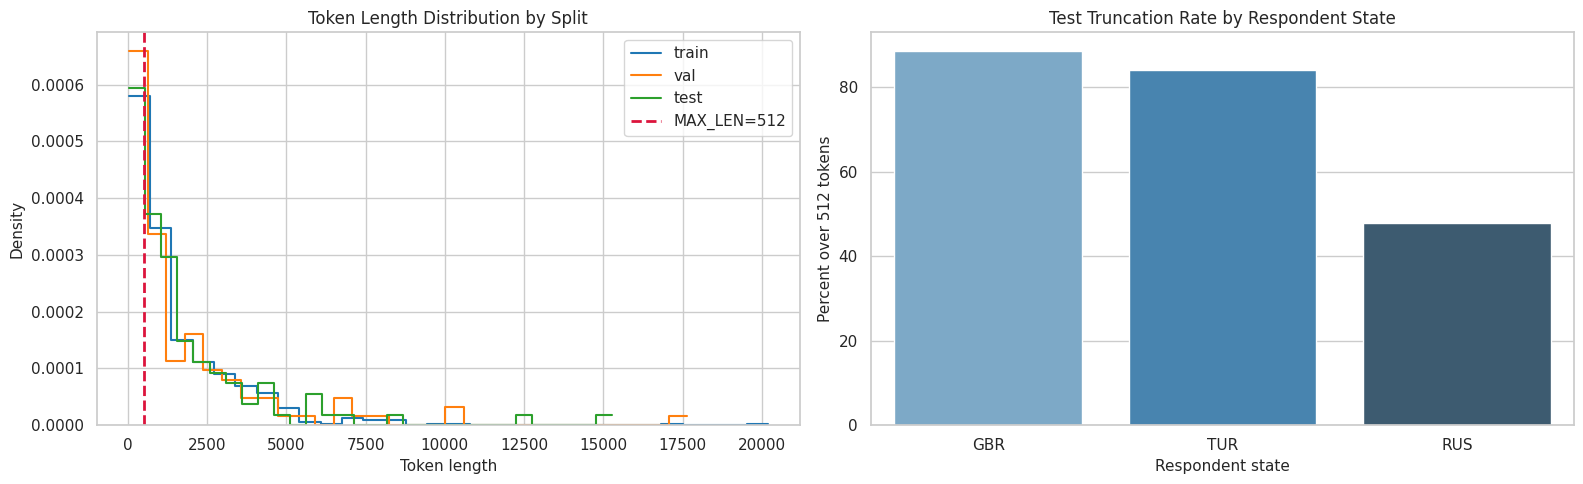

In [6]:
from transformers import AutoTokenizer


def batch_token_lengths(tokenizer, texts, batch_size=32):
    lengths = []
    texts = [str(text) for text in texts]
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False,
            return_attention_mask=False,
            return_length=True,
        )
        lengths.extend(encoded['length'])
    return np.asarray(lengths)


base_model_dir = ensure_legal_bert_base_model()
length_tokenizer = AutoTokenizer.from_pretrained(base_model_dir)
length_tokenizer.model_max_length = int(1e9)

split_frames = {
    'train': train_df.copy(),
    'val': val_df.copy(),
    'test': test_df.copy(),
}

diagnostics_frames = []
summary_rows = []
for split_name, split_df in split_frames.items():
    token_lengths = batch_token_lengths(length_tokenizer, split_df['text'].fillna('').tolist())
    diag_df = split_df[['item_id', 'respondent', 'year', 'label']].copy()
    diag_df['split'] = split_name
    diag_df['token_length'] = token_lengths
    diag_df['over_max_len'] = diag_df['token_length'] > MAX_LEN
    diag_df['tokens_lost_if_truncated'] = np.maximum(diag_df['token_length'] - MAX_LEN, 0)
    diagnostics_frames.append(diag_df)

    summary_rows.append({
        'split': split_name,
        'n_cases': int(len(diag_df)),
        'mean_tokens': float(diag_df['token_length'].mean()),
        'median_tokens': float(diag_df['token_length'].median()),
        'p90_tokens': float(diag_df['token_length'].quantile(0.90)),
        'p95_tokens': float(diag_df['token_length'].quantile(0.95)),
        'max_tokens': int(diag_df['token_length'].max()),
        'n_over_512': int(diag_df['over_max_len'].sum()),
        'pct_over_512': float(diag_df['over_max_len'].mean()),
        'mean_tokens_lost_among_truncated': float(
            diag_df.loc[diag_df['over_max_len'], 'tokens_lost_if_truncated'].mean()
        ) if diag_df['over_max_len'].any() else 0.0,
    })

truncation_df = pd.concat(diagnostics_frames, ignore_index=True)
truncation_summary_df = pd.DataFrame(summary_rows)
truncation_summary_df['pct_over_512'] = truncation_summary_df['pct_over_512'].map(lambda x: round(x * 100, 2))
truncation_summary_df['mean_tokens'] = truncation_summary_df['mean_tokens'].round(1)
truncation_summary_df['median_tokens'] = truncation_summary_df['median_tokens'].round(1)
truncation_summary_df['p90_tokens'] = truncation_summary_df['p90_tokens'].round(1)
truncation_summary_df['p95_tokens'] = truncation_summary_df['p95_tokens'].round(1)
truncation_summary_df['mean_tokens_lost_among_truncated'] = truncation_summary_df['mean_tokens_lost_among_truncated'].round(1)

print('Legal-BERT truncation summary')
display(truncation_summary_df)

test_truncation_by_country = (
    truncation_df[truncation_df['split'] == 'test']
    .groupby('respondent', as_index=False)
    .agg(
        n_cases=('item_id', 'size'),
        mean_tokens=('token_length', 'mean'),
        median_tokens=('token_length', 'median'),
        max_tokens=('token_length', 'max'),
        n_over_512=('over_max_len', 'sum'),
        pct_over_512=('over_max_len', 'mean'),
    )
    .sort_values(['pct_over_512', 'mean_tokens'], ascending=False)
)
test_truncation_by_country['mean_tokens'] = test_truncation_by_country['mean_tokens'].round(1)
test_truncation_by_country['median_tokens'] = test_truncation_by_country['median_tokens'].round(1)
test_truncation_by_country['pct_over_512'] = test_truncation_by_country['pct_over_512'].map(lambda x: round(x * 100, 2))

print('Test-split truncation by respondent state')
display(test_truncation_by_country)

longest_cases_df = (
    truncation_df
    .sort_values('token_length', ascending=False)
    .loc[:, ['split', 'item_id', 'respondent', 'year', 'label', 'token_length', 'tokens_lost_if_truncated']]
    .head(15)
    .reset_index(drop=True)
)
print('Longest cases in the current split files')
display(longest_cases_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for split_name, color in [('train', '#1f77b4'), ('val', '#ff7f0e'), ('test', '#2ca02c')]:
    subset = truncation_df[truncation_df['split'] == split_name]
    sns.histplot(
        subset['token_length'],
        bins=30,
        stat='density',
        element='step',
        fill=False,
        ax=axes[0],
        label=split_name,
        color=color,
    )
axes[0].axvline(MAX_LEN, color='crimson', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
axes[0].set_title('Token Length Distribution by Split')
axes[0].set_xlabel('Token length')
axes[0].set_ylabel('Density')
axes[0].legend()

country_plot_df = test_truncation_by_country.copy()
sns.barplot(data=country_plot_df, x='respondent', y='pct_over_512', hue='respondent', palette='Blues_d', dodge=False, legend=False, ax=axes[1])
axes[1].set_title('Test Truncation Rate by Respondent State')
axes[1].set_xlabel('Respondent state')
axes[1].set_ylabel('Percent over 512 tokens')

plt.tight_layout()
plt.show()


## 3.1 Train Legal-BERT

Use the blocks below when you want to rerun Legal-BERT multiple times.
Recommended workflow:
- set the base hyperparameters
- enable `weighted loss` only when you want to penalize minority-class errors more heavily
- enable `weighted sampler` only when you want balanced mini-batches during training
- enable `threshold tuning` only when you want to select the decision threshold on validation instead of using the default argmax rule
- set `FORCE_RETRAIN_LEGAL_BERT = True`
- rerun the strategy blocks, the run config block, and the training block


### Optional Block 1: Weighted Loss

This keeps the original dataset intact and changes only the loss function.
Use it when the model keeps ignoring the minority class.


In [7]:
LEGAL_BERT_USE_WEIGHTED_LOSS = True
print('weighted_loss', LEGAL_BERT_USE_WEIGHTED_LOSS)
print('weighted_loss_rule', 'inverse-frequency class weights in CrossEntropyLoss')


weighted_loss True
weighted_loss_rule inverse-frequency class weights in CrossEntropyLoss


### Optional Block 2: Weighted Sampler

This changes the composition of each training epoch by sampling minority-class cases more often.
Use it when you want to rebalance exposure without changing the loss.


In [8]:
LEGAL_BERT_USE_WEIGHTED_SAMPLER = False
print('weighted_sampler', LEGAL_BERT_USE_WEIGHTED_SAMPLER)
print('weighted_sampler_rule', 'WeightedRandomSampler with inverse-frequency sample weights')


weighted_sampler False
weighted_sampler_rule WeightedRandomSampler with inverse-frequency sample weights


### Optional Block 3: Threshold Tuning

This keeps the trained model unchanged and only changes the decision rule on top of the positive-class probability.
Use it when the logits have signal but the default decision boundary is poor.


In [10]:
LEGAL_BERT_USE_THRESHOLD_TUNING = True
LEGAL_BERT_THRESHOLD_GRID_SIZE = 181
LEGAL_BERT_THRESHOLD_METRIC = 'balanced_accuracy'
print('threshold_tuning', LEGAL_BERT_USE_THRESHOLD_TUNING)
print('threshold_grid_size', LEGAL_BERT_THRESHOLD_GRID_SIZE)
print('threshold_metric', LEGAL_BERT_THRESHOLD_METRIC)
print('threshold_rule', 'search validation thresholds on positive-class probability')


threshold_tuning True
threshold_grid_size 181
threshold_metric balanced_accuracy
threshold_rule search validation thresholds on positive-class probability


In [15]:
strategy_suffix = []
if LEGAL_BERT_USE_WEIGHTED_LOSS:
    strategy_suffix.append('wloss')
if LEGAL_BERT_USE_WEIGHTED_SAMPLER:
    strategy_suffix.append('wsampler')
if LEGAL_BERT_USE_THRESHOLD_TUNING:
    strategy_suffix.append('ttune')

base_run_name = f'ep{LEGAL_BERT_EPOCHS}_lr{LEGAL_BERT_LEARNING_RATE:.0e}_wd{LEGAL_BERT_WEIGHT_DECAY}'.replace('.', 'p')
LEGAL_BERT_RUN_NAME = base_run_name if not strategy_suffix else f"{base_run_name}_{'_'.join(strategy_suffix)}"
LEGAL_BERT_OUTPUT_DIR = RESULTS_DIR / 'legal_bert' / LEGAL_BERT_RUN_NAME
FORCE_RETRAIN_LEGAL_BERT = True

print('legal_bert_output_dir', display_path(LEGAL_BERT_OUTPUT_DIR))
print('epochs', LEGAL_BERT_EPOCHS)
print('batch_size', LEGAL_BERT_BATCH_SIZE)
print('learning_rate', LEGAL_BERT_LEARNING_RATE)
print('weight_decay', LEGAL_BERT_WEIGHT_DECAY)
print('warmup_ratio', LEGAL_BERT_WARMUP_RATIO)
print('grad_accum_steps', LEGAL_BERT_GRAD_ACCUM_STEPS)
print('early_stopping_patience', LEGAL_BERT_EARLY_STOPPING_PATIENCE)
print('early_stopping_threshold', LEGAL_BERT_EARLY_STOPPING_THRESHOLD)
print('use_weighted_loss', LEGAL_BERT_USE_WEIGHTED_LOSS)
print('use_weighted_sampler', LEGAL_BERT_USE_WEIGHTED_SAMPLER)
print('use_threshold_tuning', LEGAL_BERT_USE_THRESHOLD_TUNING)
print('threshold_grid_size', LEGAL_BERT_THRESHOLD_GRID_SIZE)
print('threshold_metric', LEGAL_BERT_THRESHOLD_METRIC)
print('force_retrain', FORCE_RETRAIN_LEGAL_BERT)


legal_bert_output_dir results/legal_bert/ep3_lr2e-05_wd0p01_wloss_ttune
epochs 3
batch_size 4
learning_rate 2e-05
weight_decay 0.01
warmup_ratio 0.1
grad_accum_steps 1
early_stopping_patience 1
early_stopping_threshold 0.0
use_weighted_loss True
use_weighted_sampler False
use_threshold_tuning True
threshold_grid_size 181
threshold_metric balanced_accuracy
force_retrain True


In [13]:
artifact_info = None
if LEGAL_BERT_ARTIFACT_DIR is not None:
    artifact_info = find_existing_transformer_artifacts(LEGAL_BERT_ARTIFACT_DIR)
elif not FORCE_RETRAIN_LEGAL_BERT:
    artifact_info = find_existing_transformer_artifacts(LEGAL_BERT_OUTPUT_DIR)

if artifact_info is None:
    if not AUTO_TRAIN_LEGAL_BERT_IF_MISSING and not FORCE_RETRAIN_LEGAL_BERT:
        raise FileNotFoundError(
            f'No cached Legal-BERT outputs found under {LEGAL_BERT_OUTPUT_DIR}. '
            'Set FORCE_RETRAIN_LEGAL_BERT = True or enable AUTO_TRAIN_LEGAL_BERT_IF_MISSING.'
        )
    artifact_info = train_legal_bert_inline(
        num_train_epochs=LEGAL_BERT_EPOCHS,
        batch_size=LEGAL_BERT_BATCH_SIZE,
        output_dir=LEGAL_BERT_OUTPUT_DIR,
        learning_rate=LEGAL_BERT_LEARNING_RATE,
        weight_decay=LEGAL_BERT_WEIGHT_DECAY,
        warmup_ratio=LEGAL_BERT_WARMUP_RATIO,
        grad_accum_steps=LEGAL_BERT_GRAD_ACCUM_STEPS,
        early_stopping_patience=LEGAL_BERT_EARLY_STOPPING_PATIENCE,
        early_stopping_threshold=LEGAL_BERT_EARLY_STOPPING_THRESHOLD,
        use_weighted_loss=LEGAL_BERT_USE_WEIGHTED_LOSS,
        use_weighted_sampler=LEGAL_BERT_USE_WEIGHTED_SAMPLER,
        use_threshold_tuning=LEGAL_BERT_USE_THRESHOLD_TUNING,
        threshold_grid_size=LEGAL_BERT_THRESHOLD_GRID_SIZE,
        threshold_metric=LEGAL_BERT_THRESHOLD_METRIC,
    )

print('legal_bert_artifact_dir', display_path(artifact_info['artifact_dir']))
print('legal_bert_mode', artifact_info['mode'])
print('legal_bert_base_dir', display_path(LEGAL_BERT_BASE_DIR))

legal_metrics_raw = json.loads(Path(artifact_info['metrics_path']).read_text())
legal_pred = pd.read_csv(artifact_info['preds_path'])
required_cols = ['item_id', 'label', 'respondent', 'year', 'prediction']
missing_cols = [c for c in required_cols if c not in legal_pred.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in Legal-BERT predictions: {missing_cols}')

if 'correct' not in legal_pred.columns:
    legal_pred['correct'] = (legal_pred['label'] == legal_pred['prediction']).astype(int)
if 'logit_0' not in legal_pred.columns or 'logit_1' not in legal_pred.columns:
    legal_pred['logit_0'] = np.nan
    legal_pred['logit_1'] = np.nan
if 'prob_1' not in legal_pred.columns and legal_pred['logit_0'].notna().all() and legal_pred['logit_1'].notna().all():
    probs = softmax_probs(legal_pred[['logit_0', 'logit_1']].to_numpy())
    legal_pred['prob_1'] = probs[:, 1]
elif 'prob_1' not in legal_pred.columns:
    legal_pred['prob_1'] = np.nan
if 'prediction_mode' not in legal_pred.columns:
    legal_pred['prediction_mode'] = legal_metrics_raw.get('prediction_mode', 'argmax')
if 'threshold_used' not in legal_pred.columns:
    legal_pred['threshold_used'] = np.nan

legal_pred = legal_pred[['item_id', 'label', 'respondent', 'year', 'prediction', 'logit_0', 'logit_1', 'prob_1', 'threshold_used', 'prediction_mode', 'correct']].copy()
legal_pred['score'] = legal_pred['prob_1']
legal_pred['model_key'] = 'legal_bert'
legal_pred['model_name'] = MODEL_DISPLAY['legal_bert']

legal_metrics = {
    'accuracy': float(legal_metrics_raw.get('accuracy', legal_metrics_raw.get('test_accuracy'))),
    'precision': float(legal_metrics_raw.get('precision', legal_metrics_raw.get('test_precision'))),
    'recall': float(legal_metrics_raw.get('recall', legal_metrics_raw.get('test_recall'))),
    'f1': float(legal_metrics_raw.get('f1', legal_metrics_raw.get('test_f1'))),
}

print('legal_bert_predictions', display_path(artifact_info['preds_path']))
print('legal_bert_metrics', display_path(artifact_info['metrics_path']))
print('legal_bert_prediction_mode', legal_metrics_raw.get('prediction_mode', 'argmax'))
if 'threshold_tuning' in legal_metrics_raw:
    print('legal_bert_threshold_tuning', legal_metrics_raw['threshold_tuning'])
print('Legal-BERT:', legal_metrics)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


class_weights [1.6544, 0.7166]
weighted_loss True
weighted_sampler False
threshold_tuning True
threshold_metric balanced_accuracy
gradient_checkpointing False
eval_accumulation_steps None
force_single_gpu False


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Balanced Accuracy
1,0.653659,0.628747,0.481132,0.954545,0.280000,0.432990,0.477364,0.623871
2,0.605053,0.615063,0.584906,0.829787,0.520000,0.639344,0.575228,0.630968
3,0.553886,0.669447,0.679245,0.825397,0.693333,0.753623,0.647082,0.669247


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


legal_bert_artifact_dir results/legal_bert/ep3_lr2e-05_wd0p01_wloss_ttune
legal_bert_mode trained_inline
legal_bert_base_dir models/legal_bert_base_uncased
legal_bert_predictions results/legal_bert/ep3_lr2e-05_wd0p01_wloss_ttune/test_predictions.csv
legal_bert_metrics results/legal_bert/ep3_lr2e-05_wd0p01_wloss_ttune/test_metrics.json
legal_bert_prediction_mode threshold_tuned
legal_bert_threshold_tuning {'best_threshold': 0.5707777777777778, 'grid_size': 181, 'threshold_metric': 'balanced_accuracy', 'val_metrics': {'accuracy': 0.6792452830188679, 'precision': 0.847457627118644, 'recall': 0.6666666666666666, 'f1': 0.746268656716418, 'macro_f1': 0.6551856104094911, 'balanced_accuracy': 0.6881720430107527}, 'test_metrics': {'accuracy': 0.6886792452830188, 'precision': 0.8571428571428571, 'recall': 0.6575342465753424, 'f1': 0.7441860465116279, 'macro_f1': 0.6732978425329224, 'balanced_accuracy': 0.70755500207555}}
Legal-BERT: {'accuracy': 0.6886792452830188, 'precision': 0.857142857142857

## 3.2 Train Longformer-4096

This section adds a long-context encoder baseline so the notebook can compare:
- classical full-text baselines
- Legal-BERT with a 512-token window
- Longformer with a 4096-token window

The default Longformer settings are intentionally conservative because 4096-token training is much heavier than Legal-BERT.


In [20]:
LONGFORMER_EPOCHS = 2
LONGFORMER_BATCH_SIZE = 5
LONGFORMER_MAX_LEN = 4096
LONGFORMER_LEARNING_RATE = 1e-5
LONGFORMER_WEIGHT_DECAY = 0.01
LONGFORMER_WARMUP_RATIO = 0.10
LONGFORMER_GRAD_ACCUM_STEPS = 2
LONGFORMER_EARLY_STOPPING_PATIENCE = 1
LONGFORMER_EARLY_STOPPING_THRESHOLD = 0.0
LONGFORMER_USE_WEIGHTED_LOSS = True
LONGFORMER_USE_WEIGHTED_SAMPLER = False
LONGFORMER_USE_THRESHOLD_TUNING = True
LONGFORMER_THRESHOLD_GRID_SIZE = 181
LONGFORMER_THRESHOLD_METRIC = 'macro_f1'
LONGFORMER_GRADIENT_CHECKPOINTING = True
LONGFORMER_EVAL_ACCUMULATION_STEPS = 8
LONGFORMER_FORCE_SINGLE_GPU = True

longformer_strategy_suffix = []
if LONGFORMER_USE_WEIGHTED_LOSS:
    longformer_strategy_suffix.append('wloss')
if LONGFORMER_USE_WEIGHTED_SAMPLER:
    longformer_strategy_suffix.append('wsampler')
if LONGFORMER_USE_THRESHOLD_TUNING:
    longformer_strategy_suffix.append('ttune')
if LONGFORMER_GRADIENT_CHECKPOINTING:
    longformer_strategy_suffix.append('gckpt')
if not longformer_strategy_suffix:
    longformer_strategy_suffix.append('baseline')

base_longformer_run_name = (
    f'ep{LONGFORMER_EPOCHS}_lr{LONGFORMER_LEARNING_RATE:.0e}_wd{LONGFORMER_WEIGHT_DECAY}_len{LONGFORMER_MAX_LEN}'
    .replace('.', 'p')
)
LONGFORMER_RUN_NAME = f"{base_longformer_run_name}_{'_'.join(longformer_strategy_suffix)}"
LONGFORMER_OUTPUT_DIR = LONGFORMER_DIR / LONGFORMER_RUN_NAME
FORCE_RETRAIN_LONGFORMER = True

print('longformer_model_name', LONGFORMER_MODEL_NAME)
print('longformer_output_dir', display_path(LONGFORMER_OUTPUT_DIR))
print('epochs', LONGFORMER_EPOCHS)
print('batch_size', LONGFORMER_BATCH_SIZE)
print('max_len', LONGFORMER_MAX_LEN)
print('learning_rate', LONGFORMER_LEARNING_RATE)
print('weight_decay', LONGFORMER_WEIGHT_DECAY)
print('warmup_ratio', LONGFORMER_WARMUP_RATIO)
print('grad_accum_steps', LONGFORMER_GRAD_ACCUM_STEPS)
print('early_stopping_patience', LONGFORMER_EARLY_STOPPING_PATIENCE)
print('early_stopping_threshold', LONGFORMER_EARLY_STOPPING_THRESHOLD)
print('use_weighted_loss', LONGFORMER_USE_WEIGHTED_LOSS)
print('use_weighted_sampler', LONGFORMER_USE_WEIGHTED_SAMPLER)
print('use_threshold_tuning', LONGFORMER_USE_THRESHOLD_TUNING)
print('threshold_grid_size', LONGFORMER_THRESHOLD_GRID_SIZE)
print('threshold_metric', LONGFORMER_THRESHOLD_METRIC)
print('gradient_checkpointing', LONGFORMER_GRADIENT_CHECKPOINTING)
print('eval_accumulation_steps', LONGFORMER_EVAL_ACCUMULATION_STEPS)
print('force_single_gpu', LONGFORMER_FORCE_SINGLE_GPU)
print('force_retrain', FORCE_RETRAIN_LONGFORMER)


longformer_model_name allenai/longformer-base-4096
longformer_output_dir results/longformer_4096/ep2_lr1e-05_wd0p01_len4096_wloss_ttune_gckpt
epochs 2
batch_size 5
max_len 4096
learning_rate 1e-05
weight_decay 0.01
warmup_ratio 0.1
grad_accum_steps 2
early_stopping_patience 1
early_stopping_threshold 0.0
use_weighted_loss True
use_weighted_sampler False
use_threshold_tuning True
threshold_grid_size 181
threshold_metric macro_f1
gradient_checkpointing True
eval_accumulation_steps 8
force_single_gpu True
force_retrain True


In [21]:
longformer_available = False
longformer_pred = None
longformer_metrics = None
longformer_artifact_info = None

if LONGFORMER_ARTIFACT_DIR is not None:
    longformer_artifact_info = find_existing_transformer_artifacts(LONGFORMER_ARTIFACT_DIR)
elif not FORCE_RETRAIN_LONGFORMER:
    longformer_artifact_info = find_existing_transformer_artifacts(LONGFORMER_OUTPUT_DIR)

if longformer_artifact_info is None and (FORCE_RETRAIN_LONGFORMER or AUTO_TRAIN_LONGFORMER_IF_MISSING):
    longformer_artifact_info = train_longformer_inline(
        num_train_epochs=LONGFORMER_EPOCHS,
        batch_size=LONGFORMER_BATCH_SIZE,
        output_dir=LONGFORMER_OUTPUT_DIR,
        learning_rate=LONGFORMER_LEARNING_RATE,
        weight_decay=LONGFORMER_WEIGHT_DECAY,
        warmup_ratio=LONGFORMER_WARMUP_RATIO,
        grad_accum_steps=LONGFORMER_GRAD_ACCUM_STEPS,
        early_stopping_patience=LONGFORMER_EARLY_STOPPING_PATIENCE,
        early_stopping_threshold=LONGFORMER_EARLY_STOPPING_THRESHOLD,
        use_weighted_loss=LONGFORMER_USE_WEIGHTED_LOSS,
        use_weighted_sampler=LONGFORMER_USE_WEIGHTED_SAMPLER,
        use_threshold_tuning=LONGFORMER_USE_THRESHOLD_TUNING,
        threshold_grid_size=LONGFORMER_THRESHOLD_GRID_SIZE,
        threshold_metric=LONGFORMER_THRESHOLD_METRIC,
        gradient_checkpointing=LONGFORMER_GRADIENT_CHECKPOINTING,
        eval_accumulation_steps=LONGFORMER_EVAL_ACCUMULATION_STEPS,
        force_single_gpu=LONGFORMER_FORCE_SINGLE_GPU,
    )

if longformer_artifact_info is None:
    print('Longformer-4096 skipped. Set FORCE_RETRAIN_LONGFORMER = True or point LONGFORMER_ARTIFACT_DIR to an existing run.')
else:
    longformer_available = True
    print('longformer_artifact_dir', display_path(longformer_artifact_info['artifact_dir']))
    print('longformer_mode', longformer_artifact_info['mode'])

    longformer_metrics_raw = json.loads(Path(longformer_artifact_info['metrics_path']).read_text())
    longformer_pred = pd.read_csv(longformer_artifact_info['preds_path'])

    required_cols = ['item_id', 'label', 'respondent', 'year', 'prediction']
    missing_cols = [c for c in required_cols if c not in longformer_pred.columns]
    if missing_cols:
        raise ValueError(f'Missing required columns in Longformer predictions: {missing_cols}')

    if 'correct' not in longformer_pred.columns:
        longformer_pred['correct'] = (longformer_pred['label'] == longformer_pred['prediction']).astype(int)
    if 'logit_0' not in longformer_pred.columns or 'logit_1' not in longformer_pred.columns:
        longformer_pred['logit_0'] = np.nan
        longformer_pred['logit_1'] = np.nan
    if 'prob_1' not in longformer_pred.columns and longformer_pred['logit_0'].notna().all() and longformer_pred['logit_1'].notna().all():
        probs = softmax_probs(longformer_pred[['logit_0', 'logit_1']].to_numpy())
        longformer_pred['prob_1'] = probs[:, 1]
    elif 'prob_1' not in longformer_pred.columns:
        longformer_pred['prob_1'] = np.nan
    if 'prediction_mode' not in longformer_pred.columns:
        longformer_pred['prediction_mode'] = longformer_metrics_raw.get('prediction_mode', 'argmax')
    if 'threshold_used' not in longformer_pred.columns:
        longformer_pred['threshold_used'] = np.nan

    longformer_pred = longformer_pred[['item_id', 'label', 'respondent', 'year', 'prediction', 'logit_0', 'logit_1', 'prob_1', 'threshold_used', 'prediction_mode', 'correct']].copy()
    longformer_pred['score'] = longformer_pred['prob_1']
    longformer_pred['model_key'] = 'longformer_4096'
    longformer_pred['model_name'] = MODEL_DISPLAY['longformer_4096']

    longformer_metrics = {
        'accuracy': float(longformer_metrics_raw.get('accuracy', longformer_metrics_raw.get('test_accuracy'))),
        'precision': float(longformer_metrics_raw.get('precision', longformer_metrics_raw.get('test_precision'))),
        'recall': float(longformer_metrics_raw.get('recall', longformer_metrics_raw.get('test_recall'))),
        'f1': float(longformer_metrics_raw.get('f1', longformer_metrics_raw.get('test_f1'))),
    }

    print('longformer_predictions', display_path(longformer_artifact_info['preds_path']))
    print('longformer_metrics', display_path(longformer_artifact_info['metrics_path']))
    print('longformer_prediction_mode', longformer_metrics_raw.get('prediction_mode', 'argmax'))
    if 'threshold_tuning' in longformer_metrics_raw:
        print('longformer_threshold_tuning', longformer_metrics_raw['threshold_tuning'])
    print('Longformer-4096:', longformer_metrics)


Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
lm_head.decoder.weight         | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.bias       | MISSING    | 
classifier.dense.bias          | MISSING    | 
classifier.out_proj.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_rati

class_weights [1.6544, 0.7166]
weighted_loss True
weighted_sampler False
threshold_tuning True
threshold_metric macro_f1
gradient_checkpointing True
eval_accumulation_steps 8
force_single_gpu True


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Balanced Accuracy
1,1.322557,0.660457,0.613208,0.886364,0.520000,0.655462,0.607301,0.679355
2,1.221536,0.641703,0.650943,0.839286,0.626667,0.717557,0.630384,0.668172


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['longformer.embeddings.LayerNorm.weight', 'longformer.embeddings.LayerNorm.bias', 'longformer.encoder.layer.0.attention.output.LayerNorm.weight', 'longformer.encoder.layer.0.attention.output.LayerNorm.bias', 'longformer.encoder.layer.0.output.LayerNorm.weight', 'longformer.encoder.layer.0.output.LayerNorm.bias', 'longformer.encoder.layer.1.attention.output.LayerNorm.weight', 'longformer.encoder.layer.1.attention.output.LayerNorm.bias', 'longformer.encoder.layer.1.output.LayerNorm.weight', 'longformer.encoder.layer.1.output.LayerNorm.bias', 'longformer.encoder.layer.2.attention.output.LayerNorm.weight', 'longformer.encoder.layer.2.attention.output.LayerNorm.bias', 'longformer.encoder.layer.2.output.LayerNorm.weight', 'longformer.encoder.layer.2.output.LayerNorm.bias', 'longformer.encoder.layer.3.attention.output.LayerNorm.weight', 'longformer.encoder.layer.3.attention.output.LayerNorm.bias', 'longformer.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

longformer_artifact_dir results/longformer_4096/ep2_lr1e-05_wd0p01_len4096_wloss_ttune_gckpt
longformer_mode trained_inline
longformer_predictions results/longformer_4096/ep2_lr1e-05_wd0p01_len4096_wloss_ttune_gckpt/test_predictions.csv
longformer_metrics results/longformer_4096/ep2_lr1e-05_wd0p01_len4096_wloss_ttune_gckpt/test_metrics.json
longformer_prediction_mode threshold_tuned
longformer_threshold_tuning {'best_threshold': 0.4237777777777778, 'grid_size': 181, 'threshold_metric': 'macro_f1', 'val_metrics': {'accuracy': 0.7924528301886793, 'precision': 0.8192771084337349, 'recall': 0.9066666666666666, 'f1': 0.8607594936708861, 'macro_f1': 0.7266760431317394, 'balanced_accuracy': 0.7113978494623656}, 'test_metrics': {'accuracy': 0.6792452830188679, 'precision': 0.7349397590361446, 'recall': 0.8356164383561644, 'f1': 0.782051282051282, 'macro_f1': 0.5874542124542125, 'balanced_accuracy': 0.5844748858447488}}
Longformer-4096: {'accuracy': 0.6792452830188679, 'precision': 0.7349397590

## 4. Consolidated Comparison Table


In [22]:
metric_rows = [
    {'model_key': 'naive_bayes_word', 'model_name': MODEL_DISPLAY['naive_bayes_word'], **nb_metrics},
    {'model_key': 'linear_svm_char', 'model_name': MODEL_DISPLAY['linear_svm_char'], **svm_metrics},
    {'model_key': 'legal_bert', 'model_name': MODEL_DISPLAY['legal_bert'], **legal_metrics},
]
if longformer_available and longformer_metrics is not None:
    metric_rows.append({'model_key': 'longformer_4096', 'model_name': MODEL_DISPLAY['longformer_4096'], **longformer_metrics})

metrics_df = pd.DataFrame(metric_rows).sort_values('f1', ascending=False).reset_index(drop=True)
metrics_df


,model_key,model_name,accuracy,precision,recall,f1,macro_f1,balanced_accuracy
0,naive_bayes_word,Naive Bayes,0.745283,0.828571,0.794521,0.811189,0.709942,0.715442
1,linear_svm_char,Linear SVM,0.745283,0.838235,0.780822,0.808511,0.714114,0.723744
2,longformer_4096,Longformer-4096,0.679245,0.734940,0.835616,0.782051,NaN,NaN
3,legal_bert,Legal-BERT,0.688679,0.857143,0.657534,0.744186,NaN,NaN


In [ ]:
display_cols = ['model_name', 'accuracy', 'precision', 'recall', 'f1']
metrics_long = metrics_df[display_cols].melt(
    id_vars='model_name',
    var_name='metric',
    value_name='value',
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=metrics_long,
    x='metric',
    y='value',
    hue='model_name',
    palette=MODEL_COLORS,
)
ax.set_ylim(0, 1.05)
ax.set_title('Test Metrics by Model')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Confusion Matrices

This is the most useful sanity check. A model can show a decent F1 in an imbalanced setting while still making a degenerate decision rule.


In [ ]:
prediction_frames = [nb_pred, svm_pred, legal_pred]
if longformer_available and longformer_pred is not None:
    prediction_frames.append(longformer_pred)

fig, axes = plt.subplots(1, len(prediction_frames), figsize=(5 * len(prediction_frames), 4))
axes = np.atleast_1d(axes)

for ax, pred_df in zip(axes, prediction_frames):
    cm = confusion_matrix(pred_df['label'], pred_df['prediction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(pred_df['model_name'].iloc[0])
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()
plt.show()


## 6. Prediction Distribution

This plot compares each model's predicted positive rate against the actual test-set positive rate.


In [ ]:
pred_rate_rows = []
for pred_df in prediction_frames:
    pred_rate_rows.append({
        'model_name': pred_df['model_name'].iloc[0],
        'predicted_violation_rate': pred_df['prediction'].mean(),
        'actual_violation_rate': pred_df['label'].mean(),
    })

pred_rate_df = pd.DataFrame(pred_rate_rows)
pred_rate_long = pred_rate_df.melt(
    id_vars='model_name',
    var_name='rate_type',
    value_name='rate',
)

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(
    data=pred_rate_long,
    x='model_name',
    y='rate',
    hue='rate_type',
    palette=['#4c78a8', '#f58518'],
)
ax.set_ylim(0, 1.05)
ax.set_title('Predicted vs Actual Violation Rate on Test Set')
ax.set_xlabel('Model')
ax.set_ylabel('Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pred_rate_df


## 7. Country-Level Comparison

This joins model predictions with the test metadata and compares:
- accuracy by respondent state
- predicted violation rate by respondent state


In [ ]:
meta_base = metadata_joined_test[['item_id', 'respondent', 'year', 'judgementdate']].copy()
meta_base['item_id'] = meta_base['item_id'].astype(str)

country_frames = []
for pred_df in prediction_frames:
    merged = pred_df.copy()
    merged['item_id'] = merged['item_id'].astype(str)
    merged = merged.merge(meta_base, on='item_id', how='left', suffixes=('', '_meta'))
    if 'respondent_meta' in merged.columns:
        merged['respondent'] = merged['respondent'].fillna(merged['respondent_meta'])
    country_frames.append(merged)

all_preds = pd.concat(country_frames, ignore_index=True)

country_eval = all_preds.groupby(['model_name', 'respondent']).agg(
    accuracy=('correct', 'mean'),
    predicted_violation_rate=('prediction', 'mean'),
    cases=('item_id', 'count'),
).reset_index()

country_eval


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=country_eval,
    x='respondent',
    y='accuracy',
    hue='model_name',
    palette=MODEL_COLORS,
    ax=axes[0],
)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Accuracy by Respondent State')
axes[0].set_xlabel('Respondent')
axes[0].set_ylabel('Accuracy')

sns.barplot(
    data=country_eval,
    x='respondent',
    y='predicted_violation_rate',
    hue='model_name',
    palette=MODEL_COLORS,
    ax=axes[1],
)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Predicted Violation Rate by Respondent State')
axes[1].set_xlabel('Respondent')
axes[1].set_ylabel('Predicted violation rate')

axes[0].legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].legend_.remove()
plt.tight_layout()
plt.show()


## 8. Score Distribution by True Label

For the classical models, `score` is a probability or decision score. For Legal-BERT, `score` is the positive-class probability (`prob_1`).
This helps distinguish a genuinely discriminative model from one that collapses into one class.


In [ ]:
score_frames = [
    nb_pred[['label', 'score', 'model_name']].copy(),
    svm_pred[['label', 'score', 'model_name']].copy(),
    legal_pred[['label', 'score', 'model_name']].copy(),
]
if longformer_available and longformer_pred is not None:
    score_frames.append(longformer_pred[['label', 'score', 'model_name']].copy())

score_plot_df = pd.concat(score_frames, ignore_index=True)
score_plot_df['true_label_name'] = score_plot_df['label'].map({0: 'Non-Violation', 1: 'Violation'})

model_order = ['Naive Bayes', 'Linear SVM', 'Legal-BERT']
if longformer_available and longformer_pred is not None:
    model_order.append('Longformer-4096')

fig, axes = plt.subplots(1, len(model_order), figsize=(5 * len(model_order), 4), sharey=False)
axes = np.atleast_1d(axes)
for ax, model_name in zip(axes, model_order):
    subset = score_plot_df[score_plot_df['model_name'] == model_name]
    sns.kdeplot(data=subset, x='score', hue='true_label_name', fill=True, common_norm=False, ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Model score')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()


## 9. Quick Read

The cell below turns the current outputs into short, decision-oriented notes.


In [ ]:
best_f1_row = metrics_df.sort_values('f1', ascending=False).iloc[0]
most_balanced_row = metrics_df.assign(balance_gap=(metrics_df['recall'] - metrics_df['precision']).abs()).sort_values(['balance_gap', 'f1']).iloc[0]
legal_pred_rate = float(legal_pred['prediction'].mean())

summary_lines = [
    f"Best F1 on the current test split: {best_f1_row['model_name']} ({best_f1_row['f1']:.4f}).",
    f"Most balanced precision/recall profile: {most_balanced_row['model_name']} (precision={most_balanced_row['precision']:.4f}, recall={most_balanced_row['recall']:.4f}).",
    f"Legal-BERT predicted violation for {legal_pred_rate:.1%} of the test set.",
]
if longformer_available and longformer_pred is not None:
    longformer_pred_rate = float(longformer_pred['prediction'].mean())
    summary_lines.append(f"Longformer-4096 predicted violation for {longformer_pred_rate:.1%} of the test set.")

for line in summary_lines:
    print('-', line)


## 10. Next Step Candidates

Once you inspect the charts, the likely next moves are:
1. Compare `Legal-BERT-512` against `Longformer-4096` to isolate the effect of the longer input window.
2. Restrict the analysis to `Article 6` and rerun the same notebook on the narrower subset.
3. Move from aggregate performance to bias diagnostics using the joined metadata test file.
